# Knox Design Analysis Notebook

Spring 2026

EC552 - Computational Synthetic Biology for Engineers

Team Members Names:

Michael Wallace

Joshua Kome

# Imports

In [1]:
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn import tree
from sklearn.model_selection import train_test_split

In [ ]:
response = requests.get(url + '/designSpace/listGroupSpaces?groupID=TestGroup1')
print(response.text)

# Knox Request Functions

In [2]:
url = 'http://localhost:8080'

def ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod="sign"):
    """
    API Request to Knox to run Rule Evaluation Algorithm.
    
    Returns:
    metrics (list of pandas DataFrames): purity_metrics, designToRule
    """
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designGroupID=" + groupID + '&' +
                             "rulesGroupID=" + ruleGroupID + '&' +
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def ruleEvaluateByDesigns(evalName, designIDs, ruleGroupID, designScores, labelingMethod="sign"):
    designSpaceIDs = listToStringList(designIDs)
    designScoresStr = listToStringList(designScores) # designScores should be a list of strings, may have to convert floats to strings before running

    # Submit Request
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designSpaceIDs=" + designSpaceIDs + '&' + 
                             "rulesGroupID=" + ruleGroupID + '&' + 
                             "designScores=" + designScoresStr + '&' + 
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def getRuleEvaluation(evalName):
    response = requests.get(url + '/rule/getEvaluation?' + "evaluationName=" + evalName)

    return processRuleEval(response)


def deleteRuleEvaluation(evalName):
    response = requests.delete(url + '/rule?' + "evaluationName=" + evalName)

    if not response.text:
        return f'"{evalName}" Sucessfully Deleted'
    else:
        return response.text
    

def processRuleEval(response):
    # Change to Pandas DataFrame
    json_data = json.loads(response.text)

    purity_metrics_df = pd.DataFrame(json_data["evaluationResults"]).T

    designToRule_df = pd.DataFrame(json_data["designToRule"], index=json_data["designToRule"]["designIDs"])
    cols = designToRule_df.columns.to_list()
    cols.remove("labels")
    cols.remove("scores")
    cols.remove("designIDs")
    cols = ["labels", "scores"] + cols
    designToRule_df = designToRule_df[cols]

    return purity_metrics_df.sort_values("impact"), designToRule_df.sort_values("scores")


def listToStringList(list_input):
    return ",".join(list_input)

# Decision Tree Functions

In [3]:
def exampleTree(X, y, **kwargs):
    # Mess around with different parameters
    
    dt_clf = tree.DecisionTreeClassifier(
        splitter=kwargs.get('splitter', 'best'),
        max_depth=kwargs.get('max_depth', None),
        min_samples_split=kwargs.get('min_samples_split', 400),
        min_samples_leaf=kwargs.get('min_samples_leaf', 200),
        max_features=kwargs.get('max_features', None),
        max_leaf_nodes=kwargs.get('max_leaf_nodes', None)
    )
    
    dt_clf = dt_clf.fit(X, y)

    return dt_clf

## Build more Trees, multiclassification and regression


# Design Analysis

### Run RuleEvaluation, debug, check dataframes, save CSVs.

In [ ]:
#deleteRuleEvaluation('test')

In [12]:
response = requests.post(url + '/rule/evaluate?' +
                           "evaluationName=test2" + '&' +
                           "designGroupID=TestGroup1" + '&' +
                           "rulesGroupID=TestRules2" + '&' +
                           "labelingMethod=median"
  )
json_data = json.loads(response.text)
print(list(json_data.keys()))
print(list(json_data["evaluationResults"].keys())[:3])

# Check what columns exist in the evaluation results
first_key = list(json_data["evaluationResults"].keys())[0]
print(json_data["evaluationResults"][first_key])

['evaluationResults', 'designToRule']
['MSW_PB2_B1_Rule_I', 'MSW_PB1_Rule_R_v1', 'MSW_B1_S1_Rule_B_v1']
{'totalImperfection': False, 'ruleSpaceID': 'MSW_PB2_B1_Rule_I', 'goodDesignsElim': 0, 'impact': 0, 'totalPerfection': True, 'numIncorrect': 3996, 'poorDesignsElim': 0, 'totalDesignsElim': 0, 'poorPerfection': False, 'poornessPercent': 100, 'numCorrect': 3996, 'goodPerfection': False, 'goodnessPercent': 100, 'poorEliminationPercent': None}


In [4]:
purity_metrics_df, designToRule_df = getRuleEvaluation('test2')

In [7]:
purity_metrics_df.to_csv("C:/Users/black/Documents/Knox_BE552/purity_metrics.csv")

In [9]:
purity_metrics_df

,totalImperfection,ruleSpaceID,goodDesignsElim,impact,totalPerfection,numIncorrect,poorDesignsElim,totalDesignsElim,poorPerfection,poornessPercent,numCorrect,goodPerfection,goodnessPercent,poorEliminationPercent
MSW_P2_Rule_M_v1,False,MSW_P2_Rule_M_v1,3514,-51,False,6056,1454,4968,False,63,1936,False,12,29
MSW_PP2_Rule_M_v1,False,MSW_PP2_Rule_M_v1,3584,-38,False,5548,2032,5616,False,49,2444,False,10,36
MSW_PH1_Rule_NI_v1,False,MSW_PH1_Rule_NI_v1,2130,-32,False,5304,822,2952,False,79,2688,False,46,27
MSW_PIn1_PH1_Rule_O,False,MSW_PIn1_PH1_Rule_O,2130,-32,False,5304,822,2952,False,79,2688,False,46,27
MSW_P1_Rule_M_v1,False,MSW_P1_Rule_M_v1,3048,-28,False,5124,1920,4968,False,51,2868,False,23,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSW_PP2_Rule_NI_v1,False,MSW_PP2_Rule_NI_v1,412,38,False,2444,1964,2376,False,50,5548,False,89,82
MSW_PIn1_PP2_Rule_O,False,MSW_PIn1_PP2_Rule_O,412,38,False,2444,1964,2376,False,50,5548,False,89,82
MSW_P2_S1_Rule_F_v1,False,MSW_P2_S1_Rule_F_v1,482,51,False,1936,2542,3024,False,36,6056,False,87,84
MSW_P2_P1_Rule_A_v1,False,MSW_P2_P1_Rule_A_v1,482,51,False,1936,2542,3024,False,36,6056,False,87,84


In [8]:
designToRule_df.to_csv("C:/Users/black/Documents/Knox_BE552/designToRule.csv")

In [10]:
designToRule_df

,labels,scores,MSW_PB2_B1_Rule_I,MSW_PB1_Rule_R_v1,MSW_B1_S1_Rule_B_v1,MSW_P1_A1_Rule_I_v1,MSW_P2_P1_Rule_A_v1,MSW_PIn1_PB1_Rule_T_v1,MSW_PH1_Rule_R_v1,MSW_PIn1_A1_Rule_B_v1,...,MSW_PIn1_PA1_Rule_T_v1,MSW_A1_B1_Rule_F_v1,MSW_B2_H1_Rule_F_v1,MSW_PA2_Rule_R_v1,MSW_S1_A1_Rule_I_v1,MSW_B1_P2_Rule_O_v1,MSW_PA1_Rule_NI_v1,MSW_PH1_Rule_M_v1,MSW_B2_P1_Rule_O,MSW_Y_H2_Rule_I
MSW_design_(181)_v1,0,-0.955420,0,0,0,0,0,1,0,1,...,1,1,0,0,0,0,0,1,0,0
MSW_design_(181),0,-0.955420,0,0,0,0,0,1,0,1,...,1,1,0,0,0,0,0,1,0,0
MSW_design_(284),0,-0.948819,0,0,0,0,0,1,0,1,...,0,1,0,0,0,0,1,1,0,0
MSW_design_(284)_v1,0,-0.948819,0,0,0,0,0,1,0,1,...,0,1,0,0,0,0,1,1,0,0
MSW_design_(277),0,-0.944792,0,0,0,0,0,1,0,0,...,1,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSW_design_(3929)_v1,1,3.437174,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,1,0,0
MSW_design_(3927)_v1,1,3.447912,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,1,0,0
MSW_design_(3927),1,3.447912,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,1,0,0
MSW_design_(3930),1,3.462357,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,1,0,0


In [ ]:
# Use this for (gnn_predicted_scores.csv) designs already have the attached scores
#evalName = 'test'
#groupID = 'TestGroup1'
#ruleGroupID = 'TestRules2'
#labelingMethod = 'median'
#purity_metrics_df, designToRule_df = ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod)

## Extract Features and Labels from designToRule_df

In [11]:
feature_names = designToRule_df.columns.to_list()[2:]
X = designToRule_df.iloc[:, 2:].to_numpy(dtype=int)
y_labels = designToRule_df["labels"].to_numpy(dtype=int)
y_scores = designToRule_df["scores"].to_numpy(dtype=float)

## Train - Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.3, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_scores, test_size=0.3, random_state=42)

In [22]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [24]:
y_train

array([1, 0, 1, ..., 0, 1, 1])

In [26]:
y_train_r

array([ 1.8393863 , -0.6781499 ,  2.0374103 , ..., -0.68347406,
        2.5277047 ,  2.2762978 ])

## Build Trees

In [29]:
# Binary Classification Tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

binary_clf = DecisionTreeClassifier(max_depth=5, min_samples_split=400, min_samples_leaf=200, random_state=42)
binary_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=200, min_samples_split=400,
                       random_state=42)

In [30]:
  # Regression Tree
reg_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=400, min_samples_leaf=200, random_state=42)
reg_tree.fit(X_train_r, y_train_r)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=200, min_samples_split=400,
                      random_state=42)

In [31]:
# Multi-Classification Tree (bin scores into quartiles)
# Use integer labels to avoid sklearn alphabetical sorting issues
y_quantile = pd.qcut(y_scores, q=4, labels=[0, 1, 2, 3])  # 0=awful, 1=poor, 2=good, 3=great
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X, y_quantile, test_size=0.3, random_state=42)

In [32]:
y_test_m

[0, 2, 1, 2, 3, ..., 3, 1, 3, 2, 2]
Length: 2398
Categories (4, int64): [0 < 1 < 2 < 3]

In [33]:
multi_clf = DecisionTreeClassifier(max_depth=5, min_samples_split=400, min_samples_leaf=200, random_state=42)
multi_clf.fit(X_train_m, y_train_m)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=200, min_samples_split=400,
                       random_state=42)

## Plot Trees

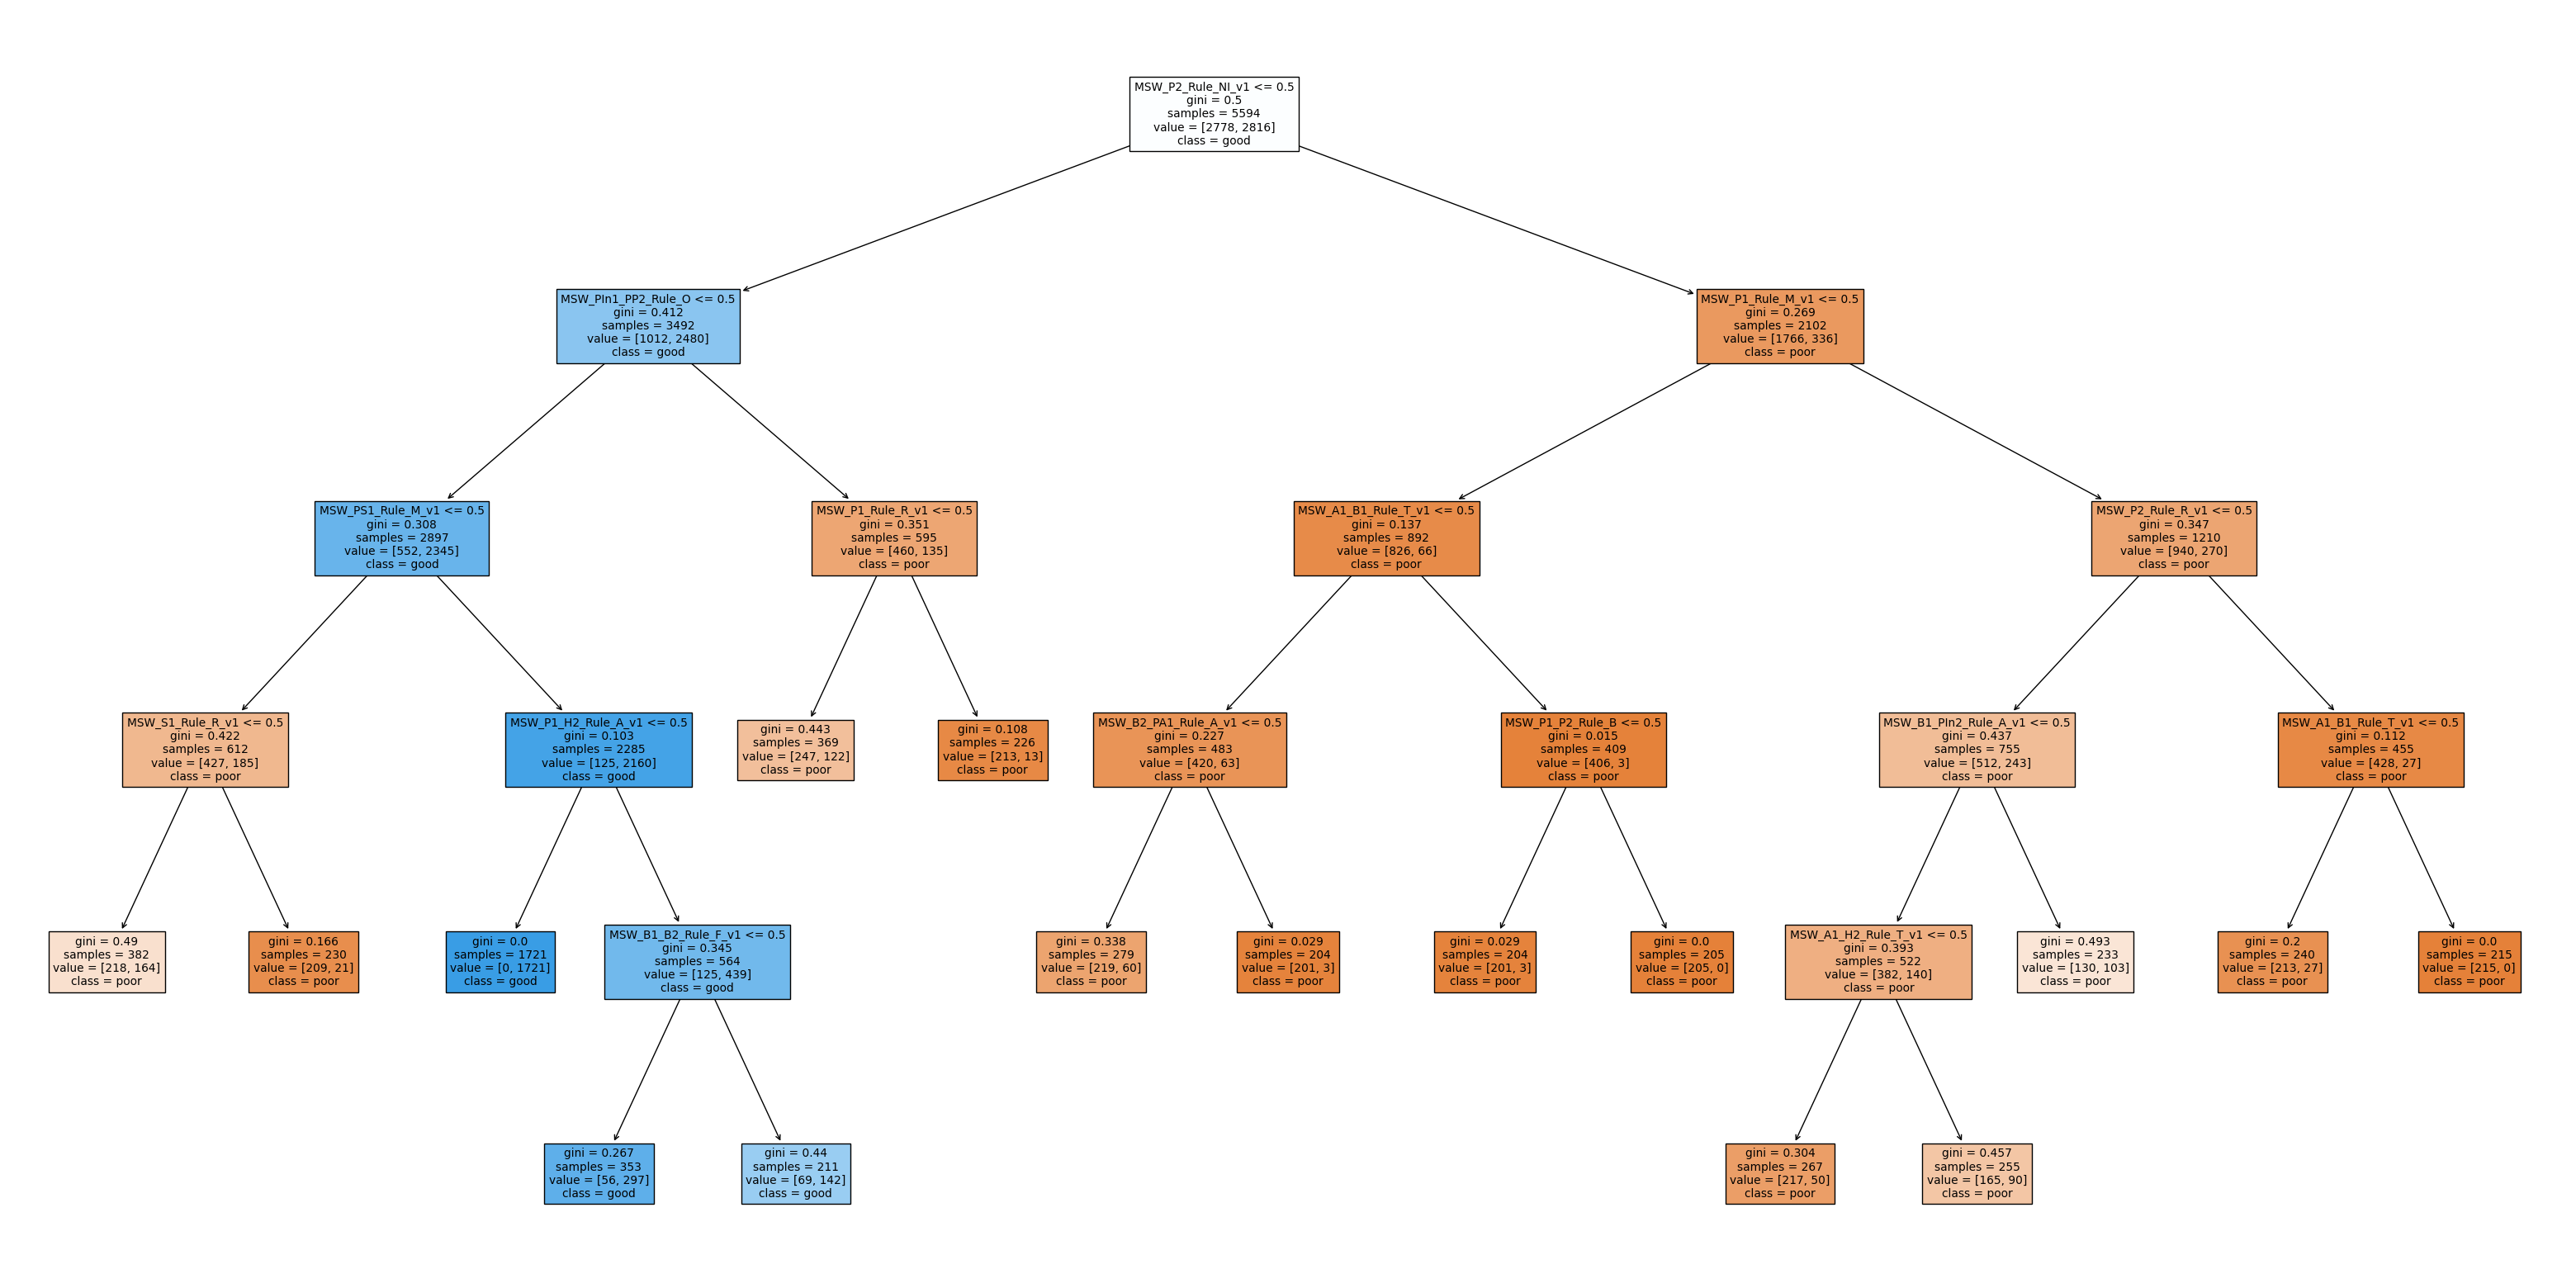

In [34]:
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(binary_clf, feature_names=feature_names, class_names=["poor", "good"], filled=True, ax=ax)
fig.savefig("binary_classification_tree.png", dpi=150, bbox_inches='tight')

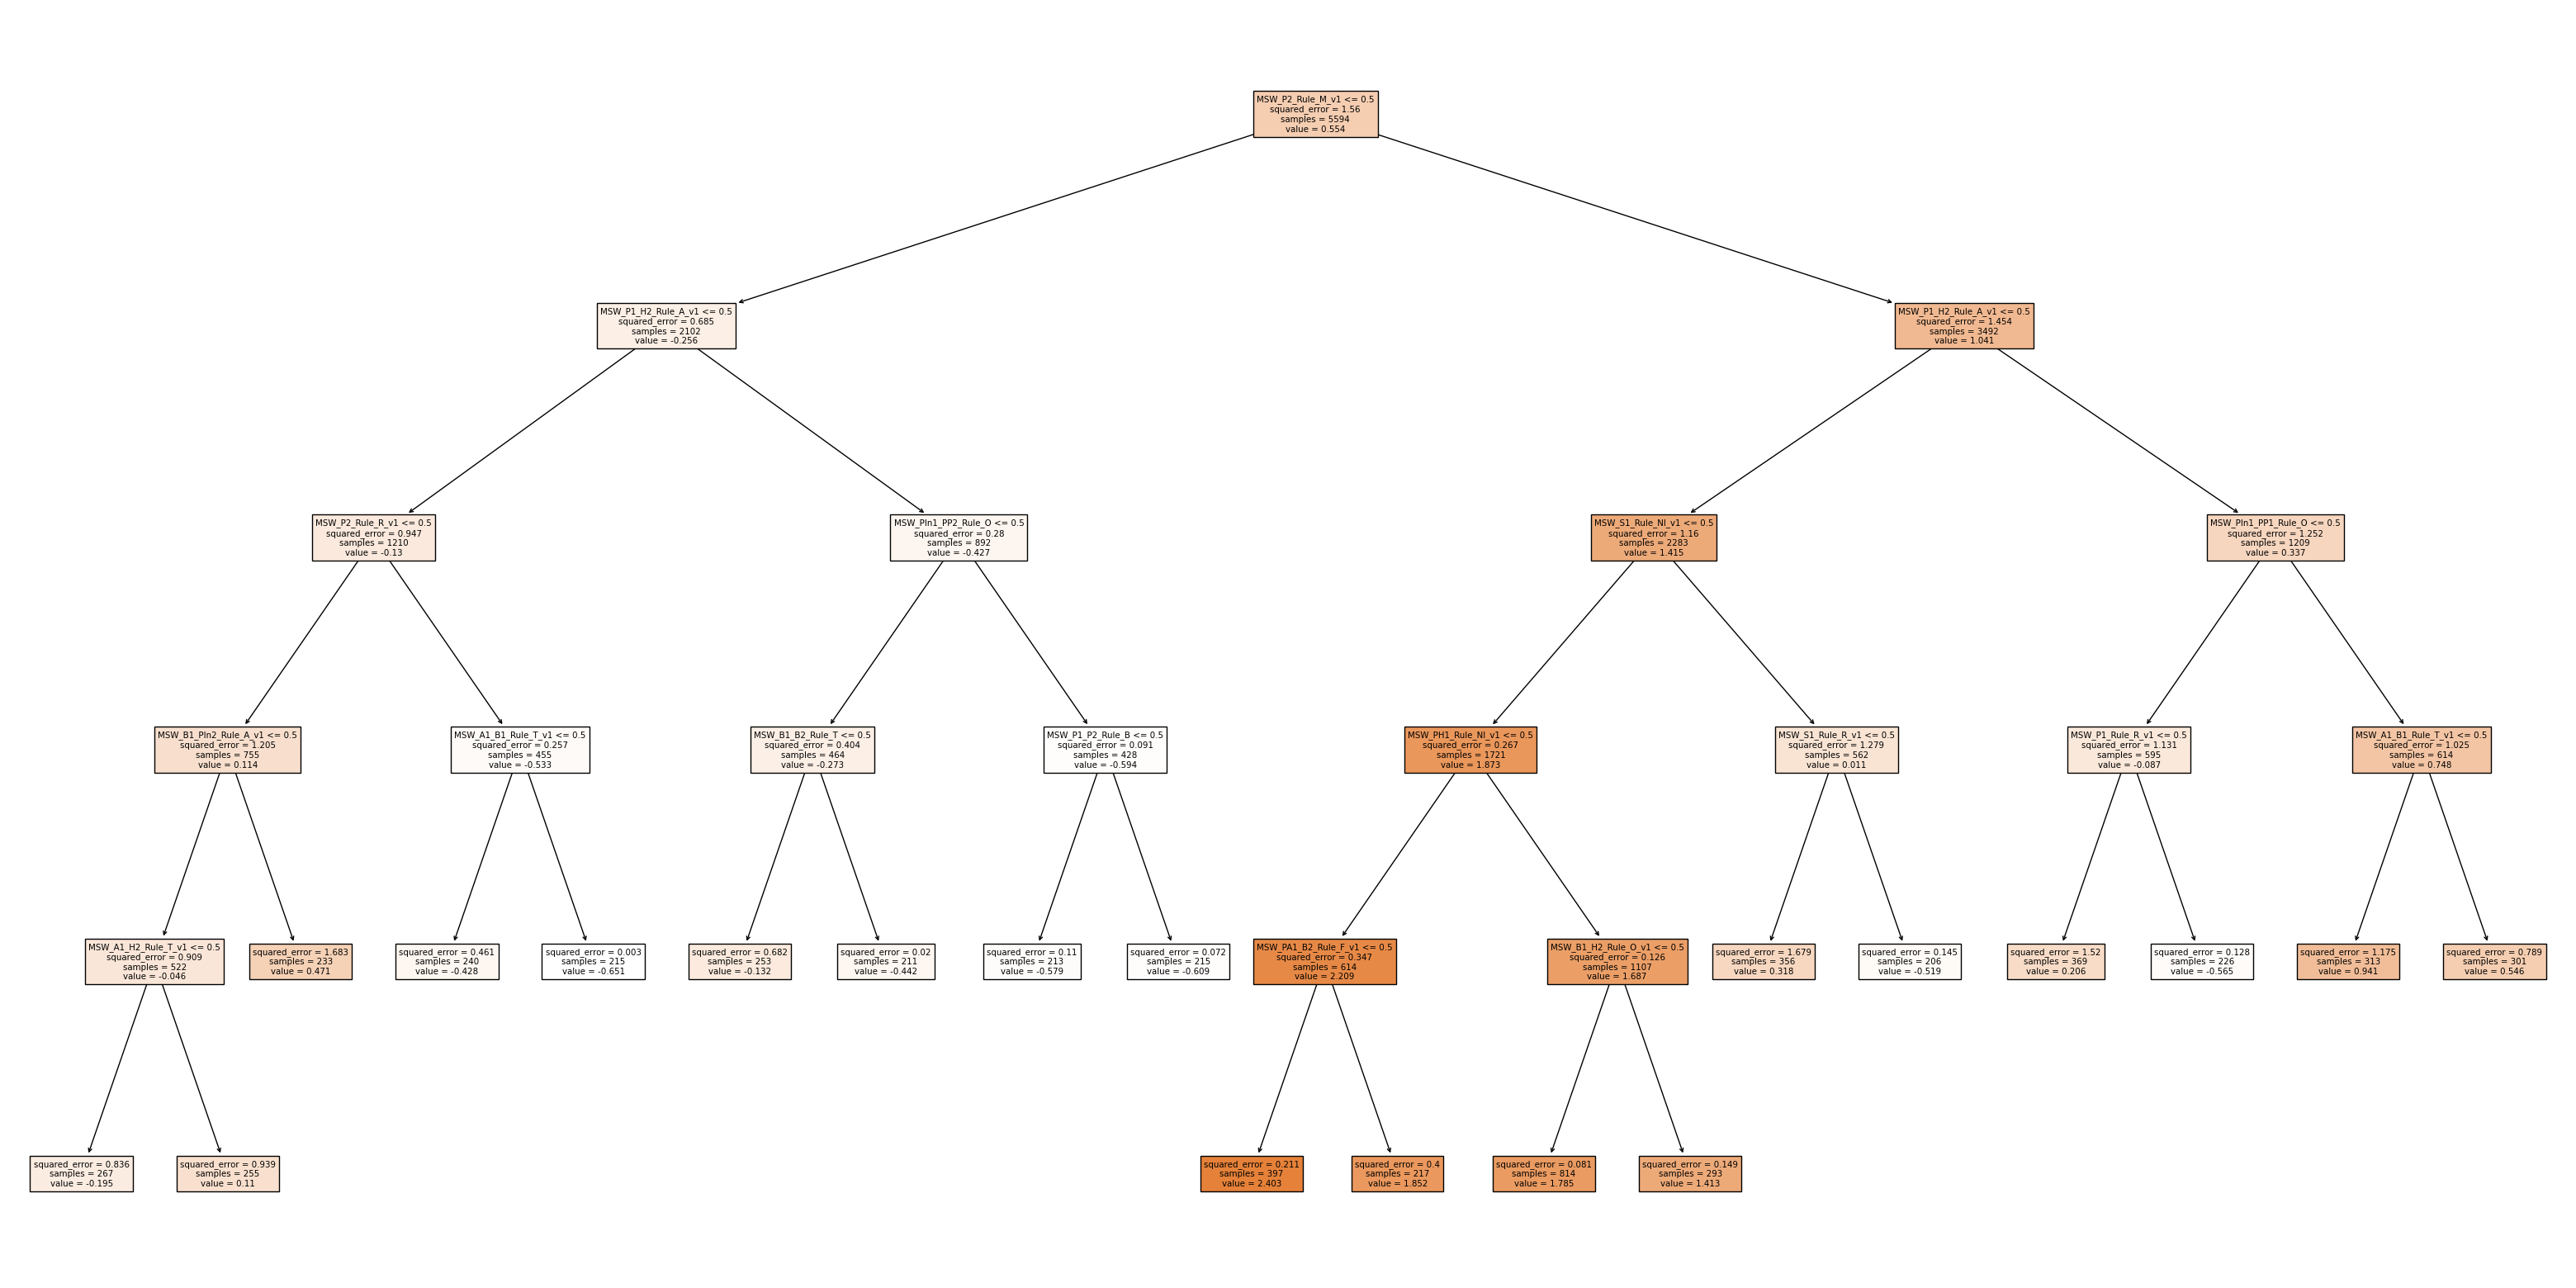

In [35]:
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(reg_tree, feature_names=feature_names, filled=True, ax=ax)
fig.savefig("regression_tree.png", dpi=150, bbox_inches='tight')

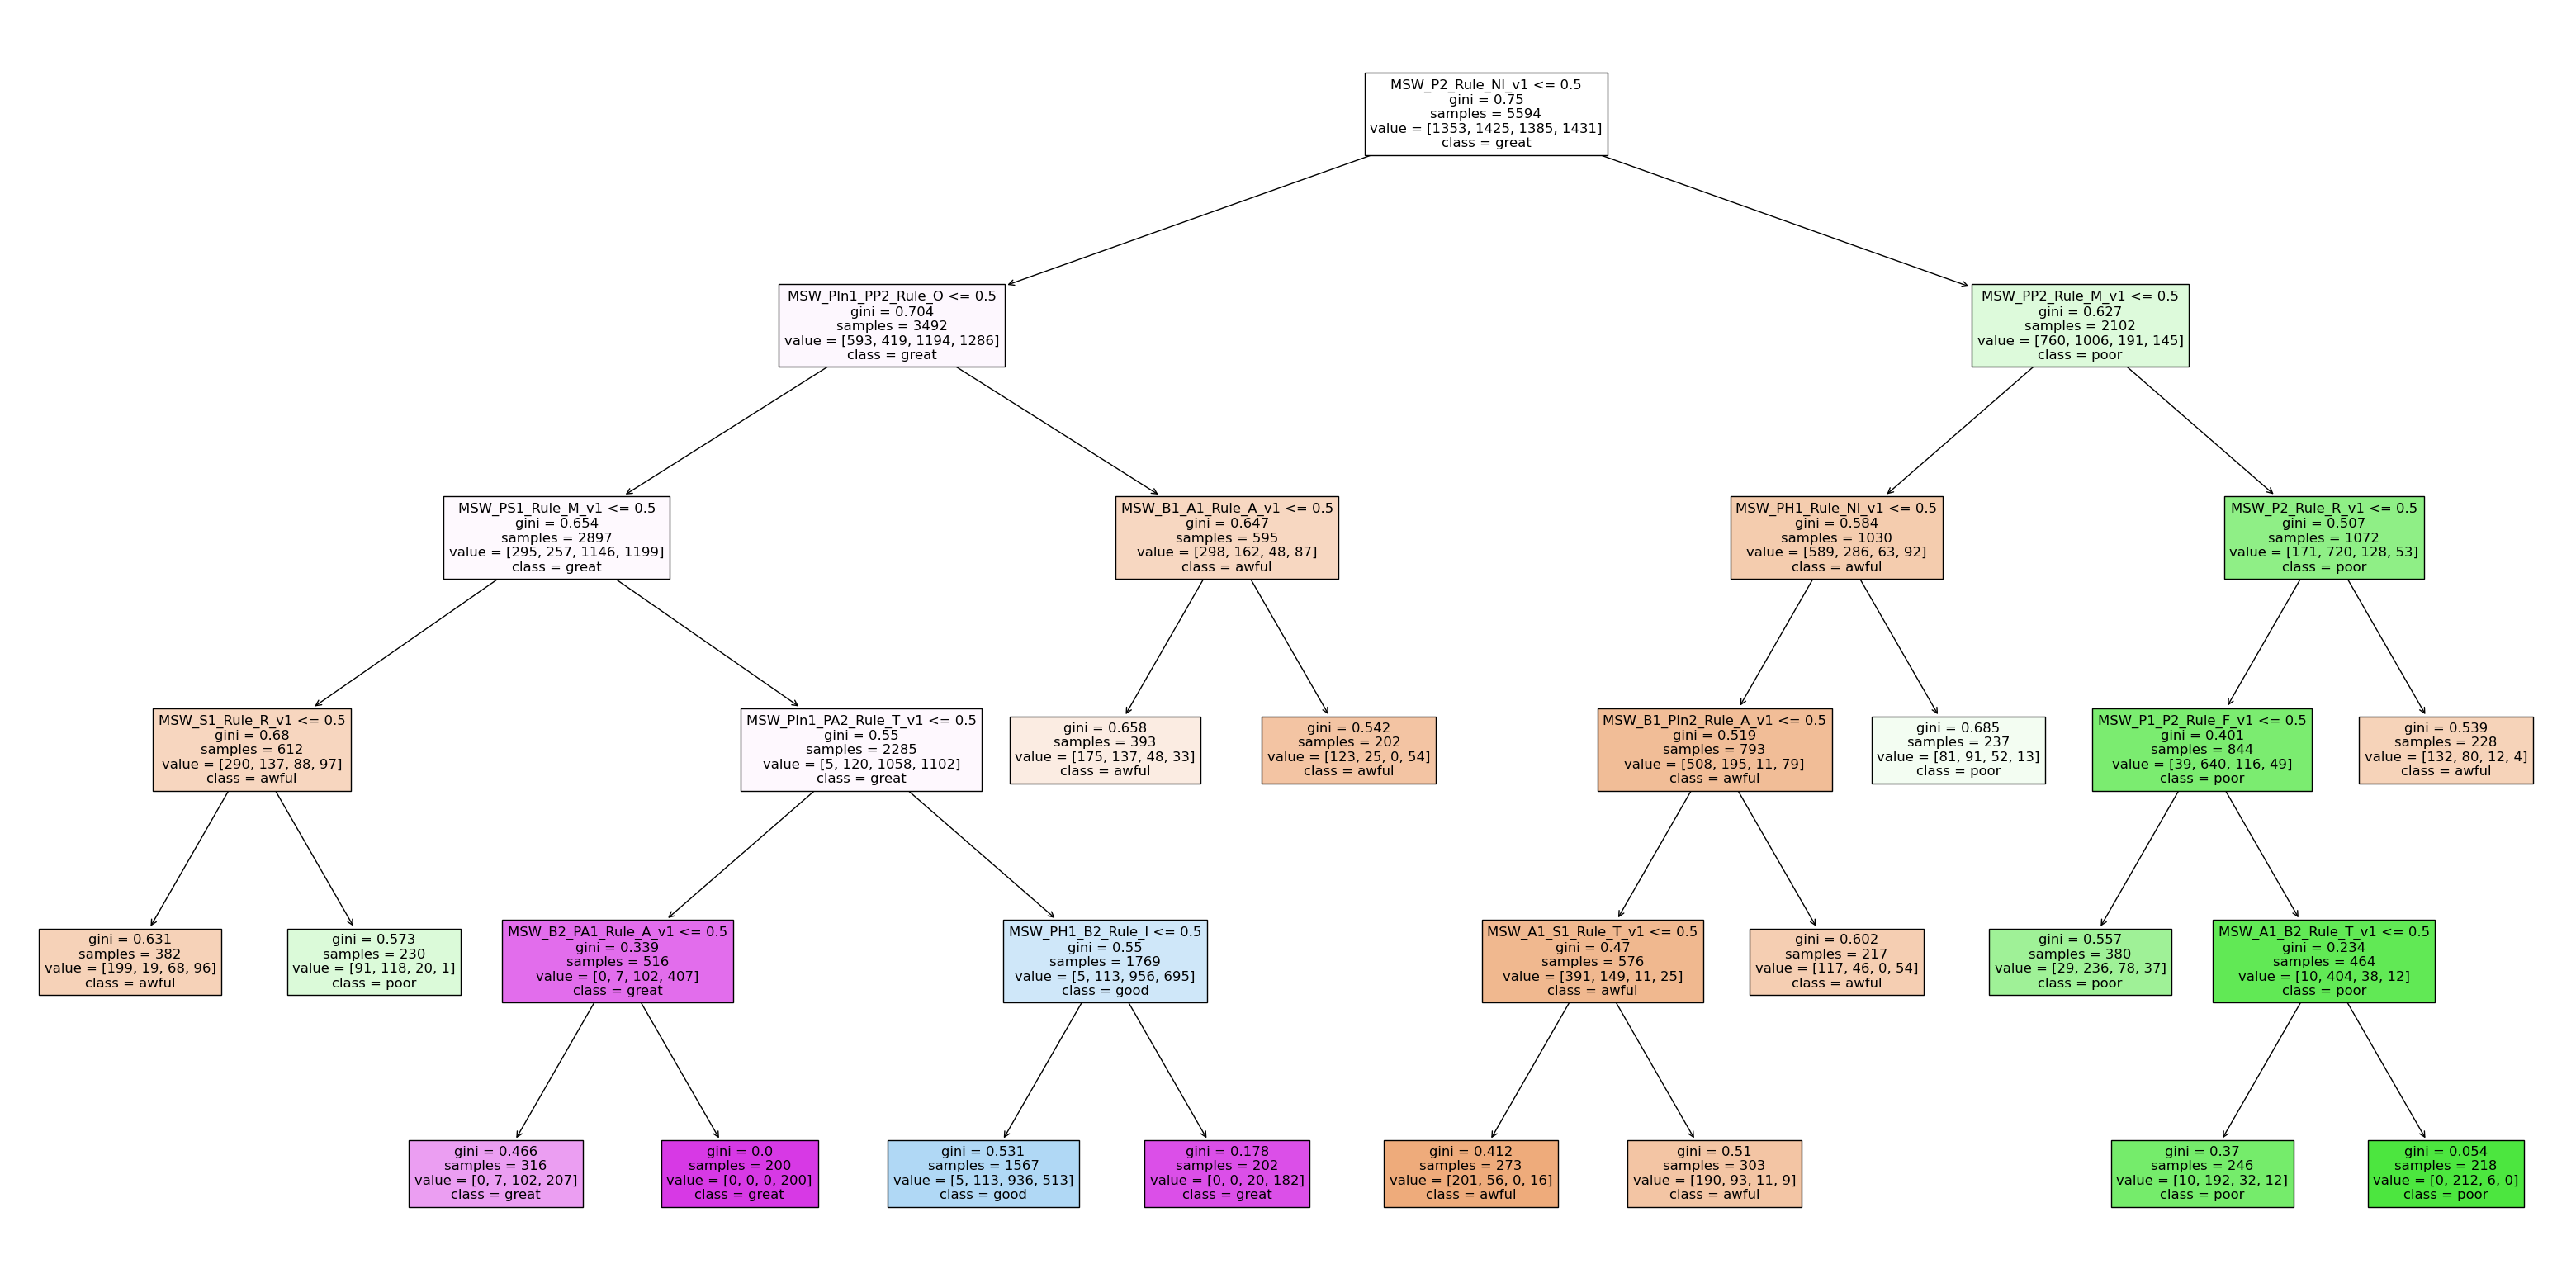

In [36]:
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(multi_clf, feature_names=feature_names, class_names=["awful", "poor", "good", "great"], filled=True,
ax=ax)
fig.savefig("multi_classification_tree.png", dpi=150, bbox_inches='tight')

## Save Trees

In [ ]:
# Done above

## Save Purity Metrics and DesignToRule DF to CSV

In [ ]:
# Done above

# Deliverables

1. Explanation of rule selection:

In [ ]:
  ┌─────────────────┬───────┬───────────────────────────────────────────────────────────────────────────────────────┐
  │    Rule Type    │ Count │                                          Why                                          │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ R (Do Not       │ 19    │ Tests if repeating any specific part hurts/helps performance — applied to all 19      │
  │ Repeat)         │       │ parts for complete coverage                                                           │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ M (Must         │ 19    │ Tests if the presence of each part correlates with good/poor designs                  │
  │ Include)        │       │                                                                                       │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ NI (Not         │ 19    │ The complement of M — tests if excluding a part correlates with performance           │
  │ Include)        │       │                                                                                       │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ S (Starts With) │ 19    │ Tests if positional placement at the start matters for each part                      │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ E (Ends With)   │ 19    │ Tests if positional placement at the end matters for each part                        │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ B (Before)      │ 42    │ Tests ordering constraints — all 36 CDS pairwise combinations plus 6 promoter-CDS     │
  │                 │       │ cross-type pairs, since part ordering is fundamental to genetic circuit function      │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ I               │ 42    │ Tests if adjacent placement of two parts is harmful — same pairing strategy as B but  │
  │ (Interference)  │       │ checks direct upstream interference                                                   │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ F (Follows)     │ 15    │ Tests if direct adjacency of specific parts is beneficial — sequential CDS pairs plus │
  │                 │       │  promoter-CDS pairs                                                                   │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ A (After)       │ 15    │ Reverse of F — tests direct downstream adjacency                                      │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ T (Together)    │ 15    │ Tests co-occurrence — do certain parts need to appear together? Mixed CDS-CDS,        │
  │                 │       │ promoter-promoter, and cross-type pairs                                               │
  ├─────────────────┼───────┼───────────────────────────────────────────────────────────────────────────────────────┤
  │ O (Not          │ 15    │ Tests mutual exclusivity — if one part is present, the other shouldn't be             │
  │ Orthogonal)     │       │                                                                                       │
  └─────────────────┴───────┴───────────────────────────────────────────────────────────────────────────────────────┘

  Why these rules: We chose to cover all single-part rules exhaustively (every part gets R, M, NI, S, E) to ensure no
  individual part effect is missed. For pairwise rules, we emphasized B and I with all CDS combinations since part
  ordering and junction interference are the most biologically relevant constraints in genetic circuit design. The
  remaining pairwise rules (F, A, T, O) use smaller representative subsets to add variety without redundancy. This gives
   the decision trees a diverse feature set to split on.

2. What are we learning from each tree type?

We are assessing the performance of rules with different granularities of circuit score as a metric. Regression tree assesses performance on the continuum of GNN data, while binary just does so in terms of good and bad, and multi-class splits good and bad further into: "awful", "poor", "good", "great".

  - Binary classification — which rules most clearly separate good from poor designs.
  - Regression — predicts the actual score, so you learn which rules have the biggest quantitative impact on
  performance, not just good/bad but how much better
  - Multi-classification — reveals if certain rules only matter at the extremes

3. What are some interesting insights you noticed about some of the rules?
- Based on the binary tree, P2 not being present generally produces better designs
- The regression tree also captures the importance of P2, where P2 not being included is the most distinguishing feature from designs being scored well vs. poorly.
- This is also represented in the multi-class tree, but we don't get many interesting insights at the extremes for the poorly-performing P2-containing designs as gini scores don't change nearly as dramatically as in the good designs.
- For example: Pin1_PA2_Rule_T splits already great designs into good and great (gini: 0.55 vs gini: 0.34), where designs with PIn1 and PA2 together perform the best.

4. If you were to experimentally validate five of these rules, which would you choose? Why?
Rules near the top of the tree give the most information on how to split the design space so these rules should be the first target to validate experimentally. We could choose one tree and take the rules in the top 2-3 layers to validate or give each rule a score based on its proximity to the root node across the three trees and take the top 5 from there. 

 # Claude Code (CLI tool) was used throughout this assignment for:

  - **GOLDBAR Generator CSV creation**: A Python script was generated to programmatically create all pairwise part
  combinations for the rule columns (B, I, F, A, T, O) and populate single-part rules (R, M, NI, S, E) for all 19 parts,
   rather than manually writing 200+ rule entries by hand.
  - **Debugging Knox API issues**: Diagnosing 500 errors from the rule evaluation endpoint, checking Neo4j database
  state, and identifying mismatched group IDs and column name casing (`"Impact"` vs `"impact"`).
  - **Sklearn boilerplate**: Generating the DecisionTreeClassifier/Regressor setup, train-test split, and plot_tree
  calls. Identified and fixed a label ordering bug where sklearn's alphabetical sorting of string class names caused
  incorrect labels in the multi-classification tree.
  - **GOLDBAR language understanding**: Interpreting rule types, writing example GOLDBAR expressions, and understanding
  graph operations (merge, and, or, join) for the walkthrough portion.

  All tree analysis, interpretation of results, and written deliverable answers reflect our own understanding of the
  data and rules.